In [1]:
# !pip install statsmodels --dry-run
!pip install statsmodels 



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# TIME SERIES FOUNDATIONS — Visual Explainer
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)

# -------------------------------------------------------
# STEP 1: Build a Synthetic Time Series with all 4 components
# -------------------------------------------------------

periods = 120  # 10 years of monthly data
time = np.arange(periods)
dates = pd.date_range(start='2014-01', periods=periods, freq='MS')

# Trend — slow upward growth
trend = 200 + 2.5 * time

# Seasonality — repeats every 12 months
seasonality = 40 * np.sin(2 * np.pi * time / 12)

# Cyclicality — a slow 5-year wave
cyclicality = 30 * np.sin(2 * np.pi * time / 60)

# Noise — pure randomness
noise = np.random.normal(0, 10, periods)

# Combined series
series = trend + seasonality + cyclicality + noise

df = pd.DataFrame({
    'value'      : series,
    'trend'      : trend,
    'seasonality': seasonality,
    'cyclicality': cyclicality,
    'noise'      : noise
}, index=dates)


In [3]:
df

,value,trend,seasonality,cyclicality,noise
2014-01-01,204.967142,200.0,0.000000,0.000000,4.967142
2014-02-01,224.253211,202.5,20.000000,3.135854,-1.382643
2014-03-01,252.355252,205.0,34.641016,6.237351,6.476885
2014-04-01,272.000808,207.5,40.000000,9.270510,15.230299
2014-05-01,254.501582,210.0,34.641016,12.202099,-2.341534
...,...,...,...,...,...
2023-08-01,455.515473,487.5,-20.000000,-15.000000,3.015473
2023-09-01,442.809767,490.0,-34.641016,-12.202099,-0.347118
2023-10-01,431.542710,492.5,-40.000000,-9.270510,-11.686780
2023-11-01,465.549861,495.0,-34.641016,-6.237351,11.428228


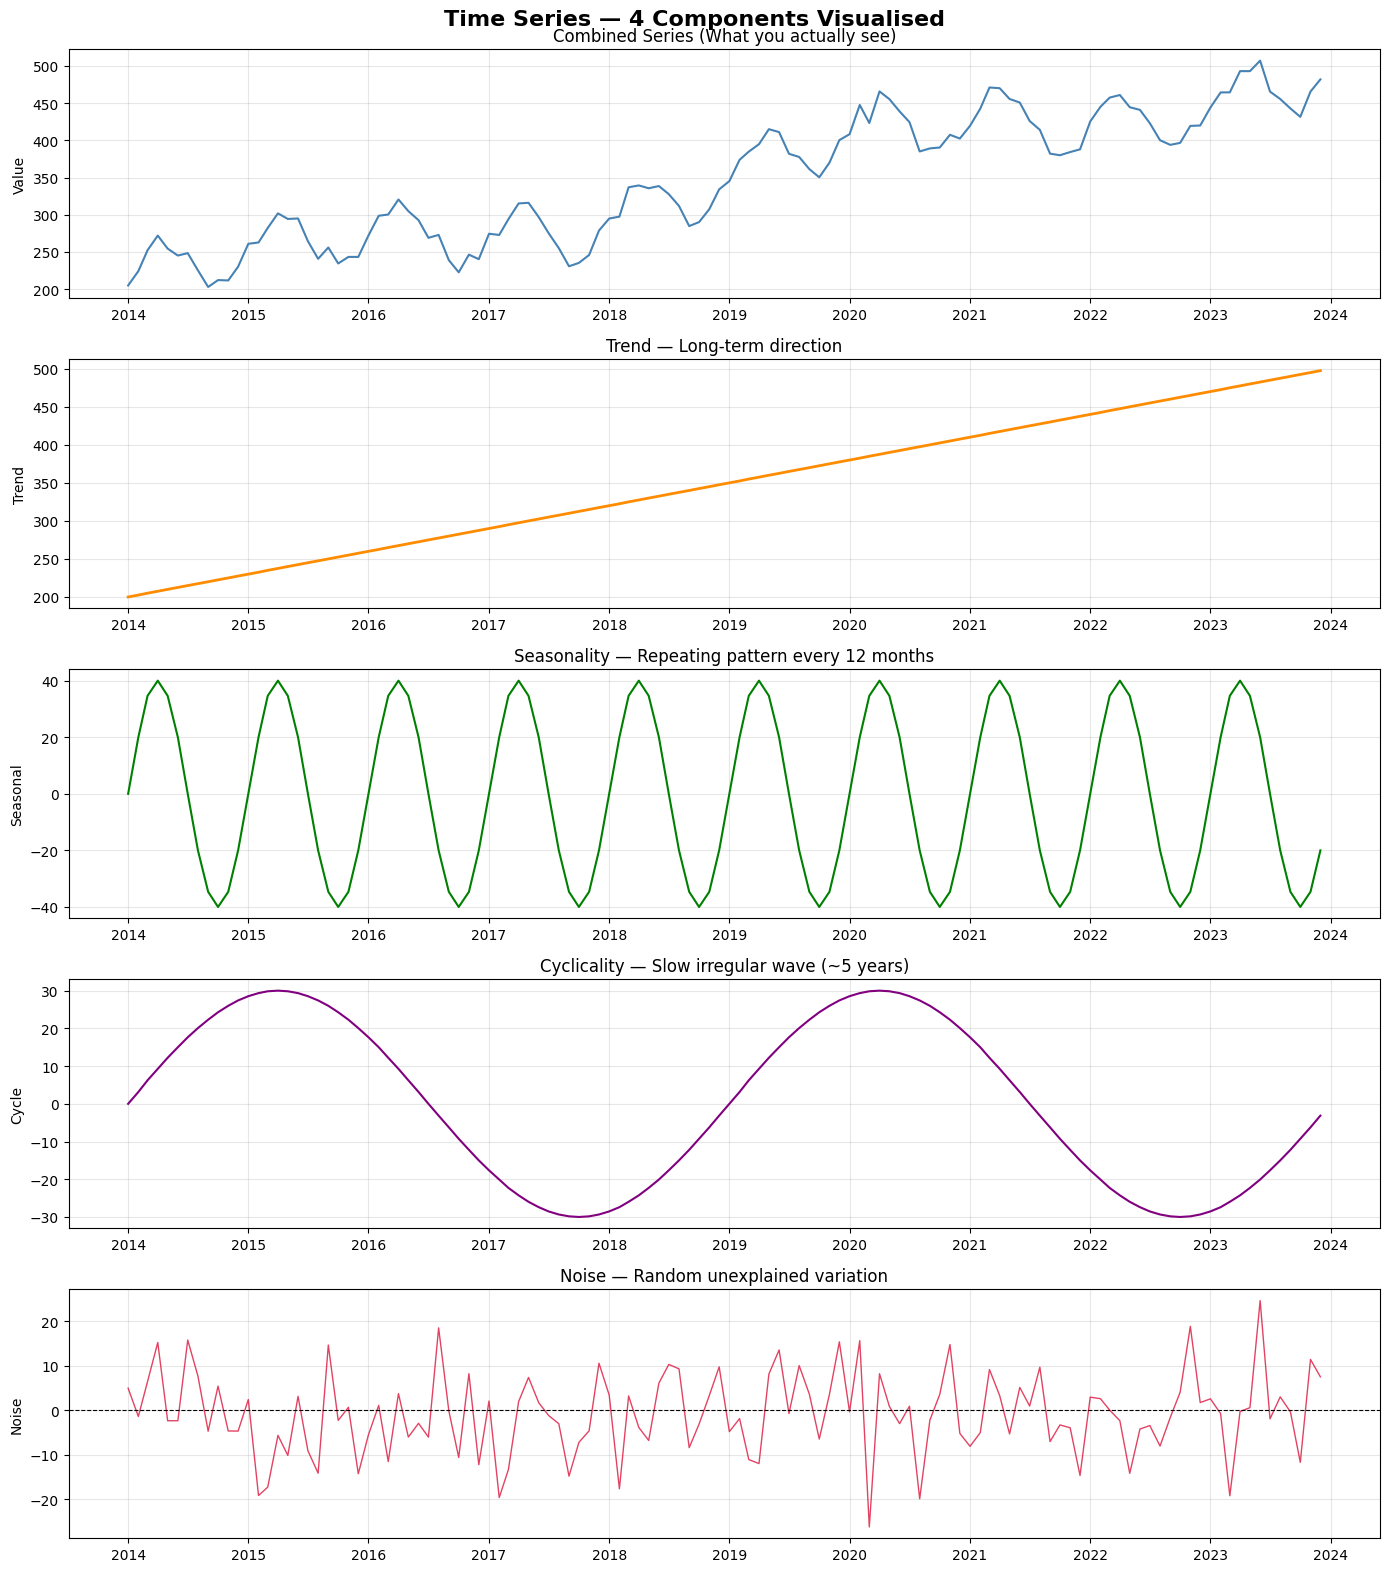

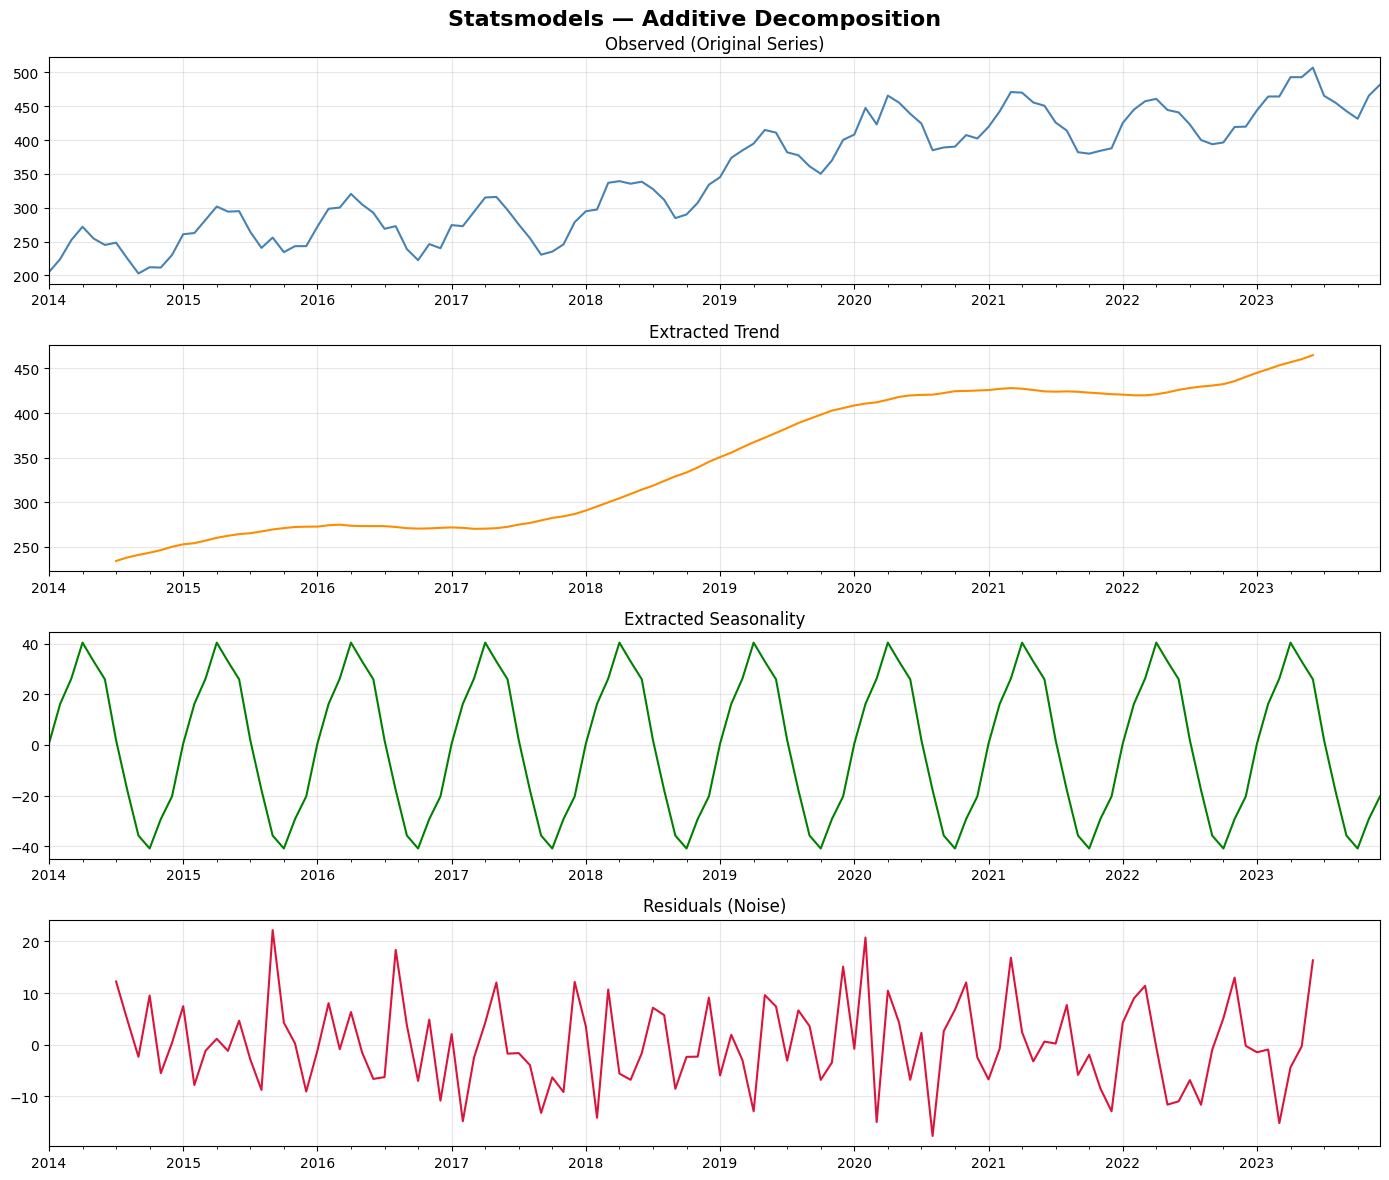

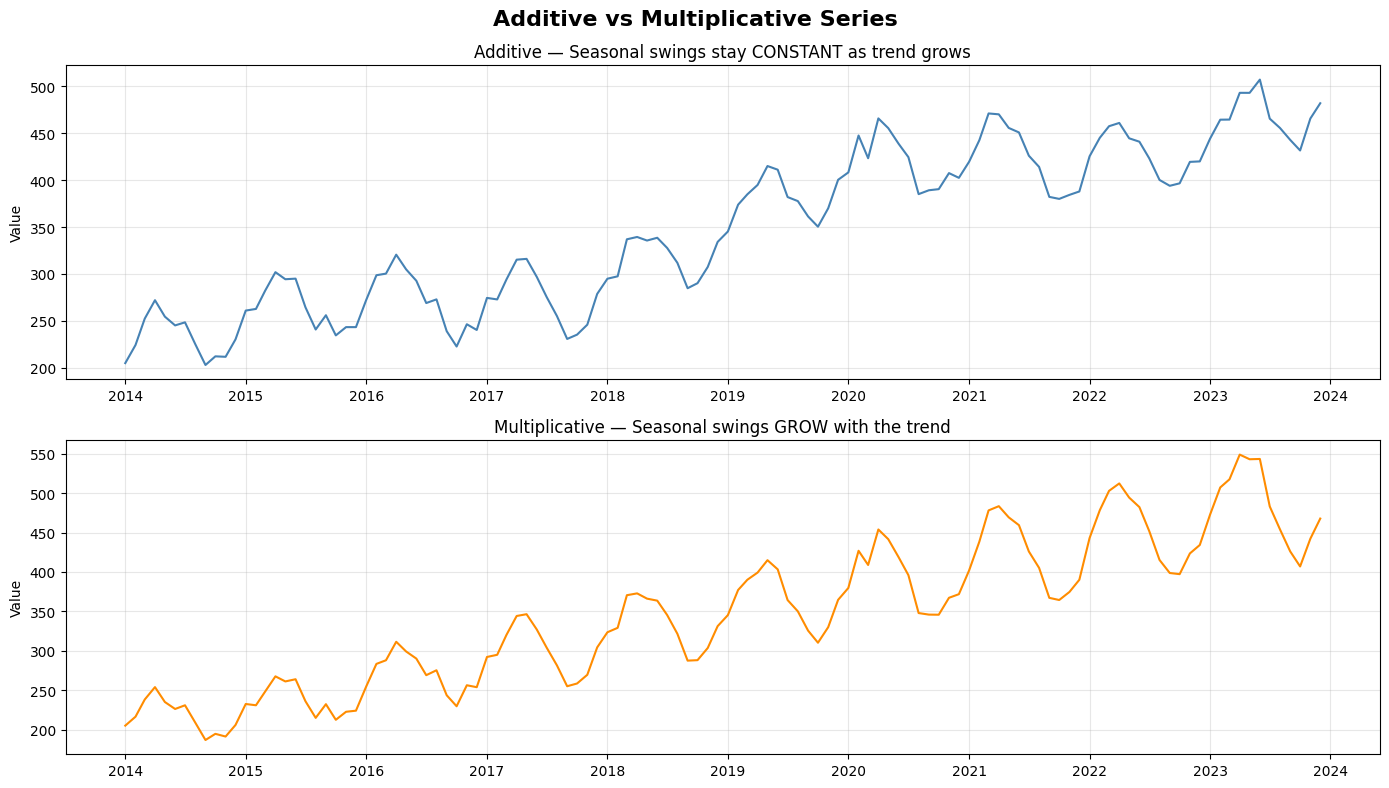

In [4]:

# -------------------------------------------------------
# STEP 2: Plot each component separately
# -------------------------------------------------------

fig, axes = plt.subplots(5, 1, figsize=(14, 16))
fig.suptitle('Time Series — 4 Components Visualised', fontsize=16, fontweight='bold')

axes[0].plot(df.index, df['value'], color='steelblue', linewidth=1.5)
axes[0].set_title('Combined Series (What you actually see)')
axes[0].set_ylabel('Value')

axes[1].plot(df.index, df['trend'], color='darkorange', linewidth=2)
axes[1].set_title('Trend — Long-term direction')
axes[1].set_ylabel('Trend')

axes[2].plot(df.index, df['seasonality'], color='green', linewidth=1.5)
axes[2].set_title('Seasonality — Repeating pattern every 12 months')
axes[2].set_ylabel('Seasonal')

axes[3].plot(df.index, df['cyclicality'], color='purple', linewidth=1.5)
axes[3].set_title('Cyclicality — Slow irregular wave (~5 years)')
axes[3].set_ylabel('Cycle')

axes[4].plot(df.index, df['noise'], color='crimson', linewidth=1, alpha=0.8)
axes[4].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[4].set_title('Noise — Random unexplained variation')
axes[4].set_ylabel('Noise')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# STEP 3: Additive Decomposition using statsmodels
# -------------------------------------------------------

decomposition = seasonal_decompose(df['value'], model='additive', period=12)

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 12))
fig2.suptitle('Statsmodels — Additive Decomposition', fontsize=16, fontweight='bold')

decomposition.observed.plot(ax=axes2[0], color='steelblue')
axes2[0].set_title('Observed (Original Series)')

decomposition.trend.plot(ax=axes2[1], color='darkorange')
axes2[1].set_title('Extracted Trend')

decomposition.seasonal.plot(ax=axes2[2], color='green')
axes2[2].set_title('Extracted Seasonality')

decomposition.resid.plot(ax=axes2[3], color='crimson')
axes2[3].set_title('Residuals (Noise)')

for ax in axes2:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# STEP 4: Additive vs Multiplicative — Side by Side
# -------------------------------------------------------

# Multiplicative series — seasonal swings grow with trend
multiplicative_series = trend * (1 + 0.15 * np.sin(2 * np.pi * time / 12)) + noise

fig3, axes3 = plt.subplots(2, 1, figsize=(14, 8))
fig3.suptitle('Additive vs Multiplicative Series', fontsize=16, fontweight='bold')

axes3[0].plot(dates, series, color='steelblue')
axes3[0].set_title('Additive — Seasonal swings stay CONSTANT as trend grows')
axes3[0].set_ylabel('Value')
axes3[0].grid(True, alpha=0.3)

axes3[1].plot(dates, multiplicative_series, color='darkorange')
axes3[1].set_title('Multiplicative — Seasonal swings GROW with the trend')
axes3[1].set_ylabel('Value')
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()